# Polynomial regression
It models nonlinear relationships between variables by adding polynomial terms 
(like (x^0, x^1, x^2, x^3, ......x^n) to a linear regression equation, allowing it to fit curves 
(parabolas, S-shapes) instead of just straight lines, making it suitable for data with curvilinear trends, 
yet remains "linear" in its parameters for estimation, fitting complex patterns without being strictly linear 
like simple regression. 

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [34]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

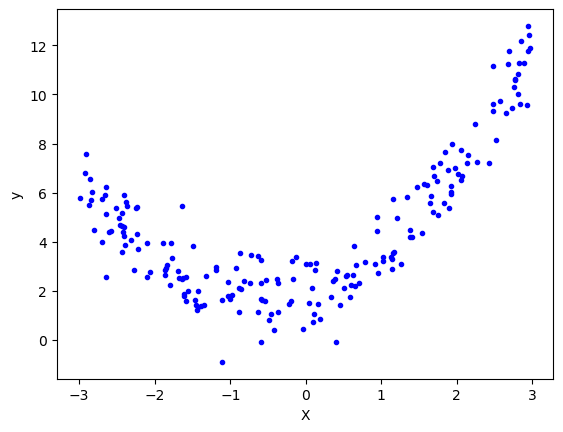

In [35]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [37]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.2318976997679233

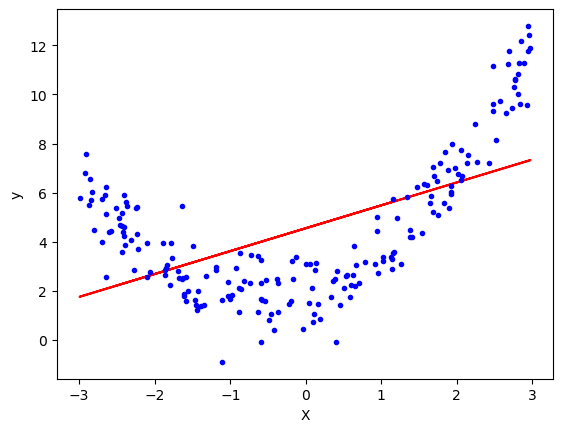

In [39]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [40]:
# Applying Polynomial Linear Regression with degree = 2

In [41]:
# it will make only two Columns from a particular Feature becouse of include_bias=False
# poly = PolynomialFeatures(degree=2, include_bias=False)  

poly = PolynomialFeatures(degree=2)  # It will give 3 columns from a particular feature

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [42]:
print(X_train[0])        # Linear
print(X_train_trans[0])  # Polynomial

[-2.50868029]
[ 1.         -2.50868029  6.29347681]


In [43]:
# include_bias_parameter
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = lr.predict(X_test_trans)

In [45]:
r2_score(y_test,y_pred)

0.8699002939947929

In [46]:
print("Coeficients : ", lr.coef_)
print("Intercept : ", lr.intercept_)

Coeficients :  [[0.         0.88620418 0.8072662 ]]
Intercept :  [1.90317811]


In [47]:
X_new = np.linspace(-3, 3, 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

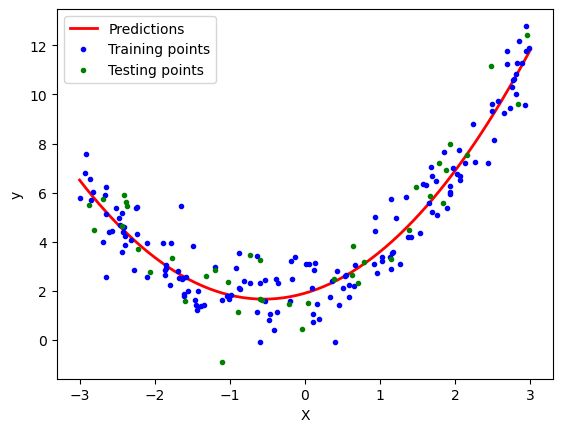

In [48]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [49]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100,1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg",lin_reg),
    ])

    polynomial_regression.fit(X,y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, 'r', label="Degree" + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

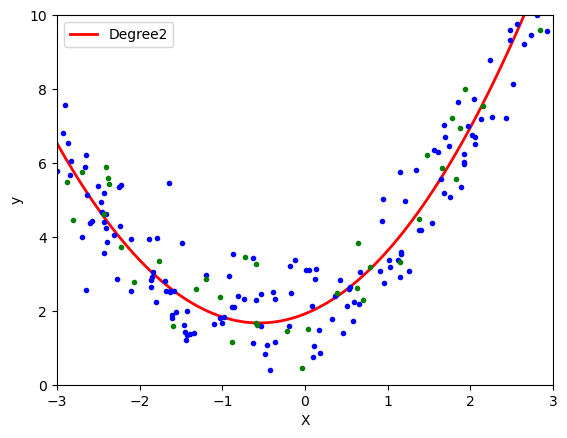

In [50]:
polynomial_regression(2)

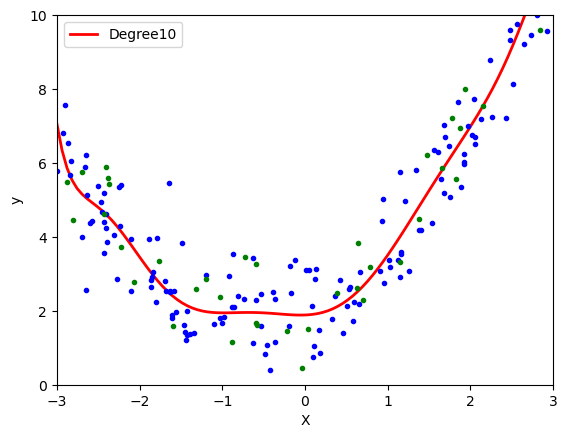

In [51]:
polynomial_regression(10)

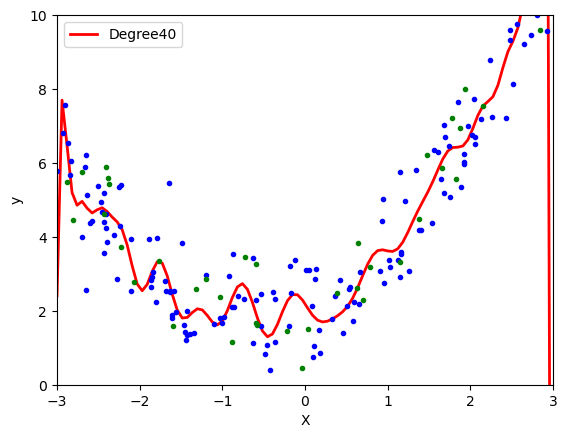

In [54]:
polynomial_regression(40)

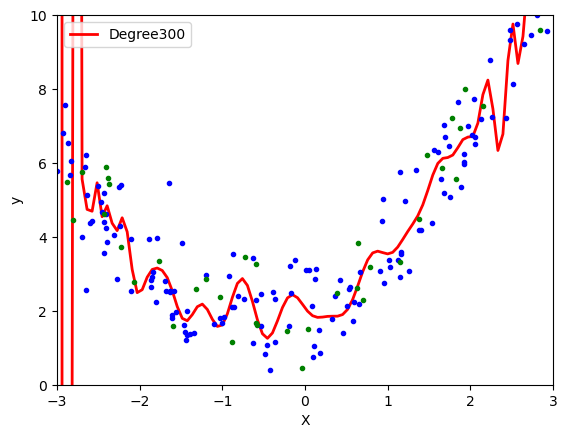

In [55]:
polynomial_regression(300) # overfitting scenarios

# 3D Polynomial Regression

In [65]:
import plotly.express as px
import plotly.graph_objects as go

In [66]:
n = 100  # Number of points
x = 7 * np.random.rand(n, 1) - 2.8
y = 7 * np.random.rand(n, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

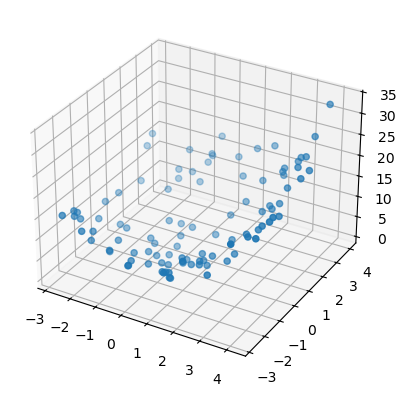

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)
plt.show()

In [68]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
# Grid for surface
x_input = np.linspace(x.min(), x.max(), 20)
y_input = np.linspace(y.min(), y.max(), 20)
xGrid, yGrid = np.meshgrid(x_input, y_input)
# Prepare grid points for prediction
# final = np.vstack((xGrid.ravel(), yGrid.ravel())).T
final = np.c_[xGrid.ravel(), yGrid.ravel()]
z_final = lr.predict(final).reshape(20, 20)

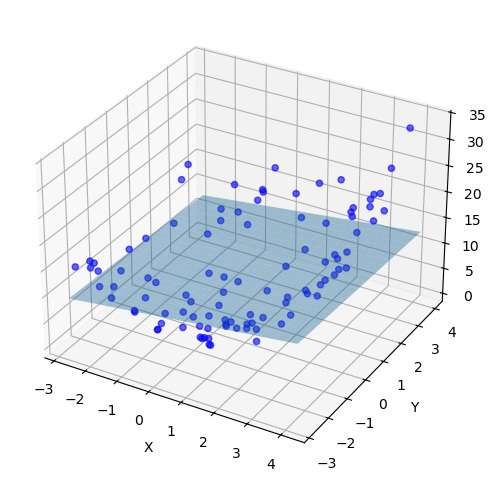

In [70]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# Scatter original points
ax.scatter(x.ravel(), y.ravel(), z.ravel(), color='blue', alpha=0.6)
ax.plot_surface(xGrid, yGrid, z_final, alpha=0.4)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [71]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [72]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

In [73]:
print("Input features:", poly.n_features_in_)
print("Output features:", poly.n_output_features_)
print("Powers:\n", poly.powers_)

Input features: 2
Output features: 6
Powers:
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [74]:
X_multi_trans.shape

(100, 6)

In [75]:
lr = LinearRegression()
lr.fit(X_multi_trans, z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
X_test_multi = poly.transform(final)

In [77]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [87]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(x.ravel(), y.ravel(), z.ravel(), color='red')
# ax.plot_surface(x_input, y_input, z_final, cmap='viridis', alpha=0.8)

# ax.set_zlim(0, 35)
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()
